# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df_base = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

# Q1 - Q2

In [3]:
df_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  str    
 2   fuel_type            10000 non-null  str    
 3   drivetrain           10000 non-null  str    
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 1.1 MB


In [4]:
df_base.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [5]:
cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df_base[cols].copy()

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

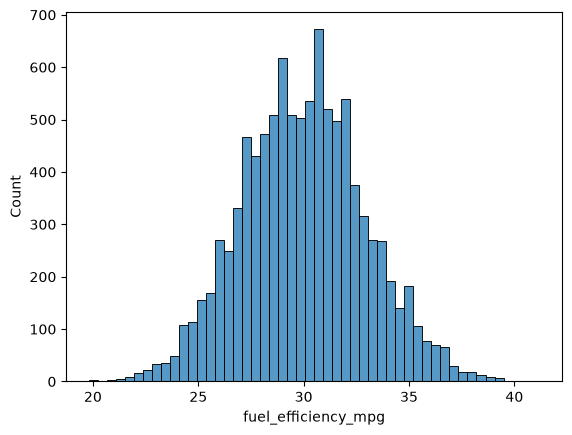

In [6]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [7]:
df.isnull().sum().sort_values(ascending=False)

horsepower             877
engine_displacement      0
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Q1. There's one column with missing values. What is it?

A1. horsepower

In [8]:
print(df.horsepower.median())

254.0


Q2. What's the median (50% percentile) for variable 'horsepower'?

A2. 254

# Q3

In [9]:
# functions
def linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def linear_regression_reg(X, y, r=0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def rmse(y_real, y_pred):
    se = (y_real - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [10]:
# validation framework
n       = len(df)
n_val   = int(n * 0.2)
n_test  = int(n * 0.2)
n_train = n - n_val - n_test

RMSE-Zero: 2.205


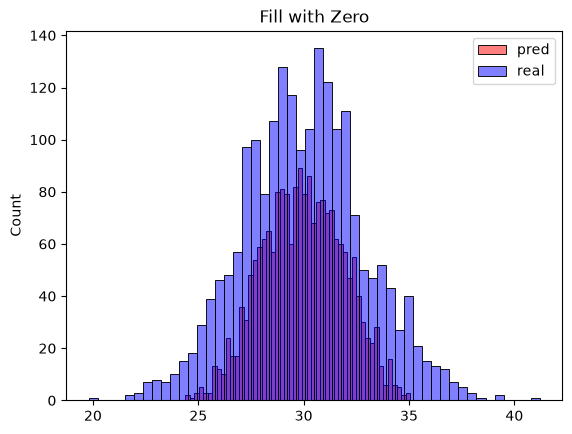

RMSE-Mean: 2.202


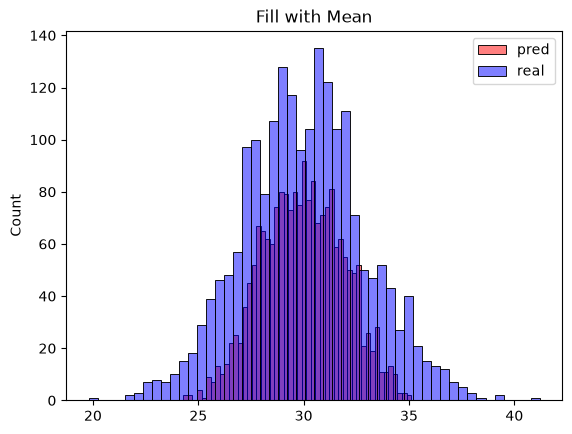

In [11]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val   = df.iloc[idx[n_train:n_train + n_val]]
df_test  = df.iloc[idx[n_train + n_val:]]

# len(df_train), len(df_val), len(df_test)

# training set
df_train_zero = df_train.copy()
df_train_zero.horsepower = df_train_zero.horsepower.fillna(0)
df_train_mean = df_train.copy()
df_train_mean.horsepower = df_train_mean.horsepower.fillna(df_train_mean.horsepower.mean())

# validation set
df_val_zero = df_val.copy()
df_val_zero.horsepower = df_val_zero.horsepower.fillna(0)
df_val_mean = df_val.copy()
df_val_mean.horsepower = df_val_mean.horsepower.fillna(df_val_mean.horsepower.mean())

feats = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

# training feat matrix and target
X_train_zero = df_train_zero[feats].values
X_train_mean = df_train_mean[feats].values
y_train_zero_real = df_train_zero[target].values
y_train_mean_real = df_train_mean[target].values

# validation feat matrix and target
X_val_zero = df_val_zero[feats].values
X_val_mean = df_val_mean[feats].values
y_val_zero_real = df_val_zero[target].values
y_val_mean_real = df_val_mean[target].values

# get feat weight from training set
w0_train_zero, w_train_zero = linear_regression(X=X_train_zero, y=y_train_zero_real)
w0_train_mean, w_train_mean = linear_regression(X=X_train_mean, y=y_train_mean_real)

# get prediction and rmse on validation targets
y_val_zero_pred = w0_train_zero + X_val_zero.dot(w_train_zero)
y_val_mean_pred = w0_train_mean + X_val_mean.dot(w_train_mean)

print(f"RMSE-Zero: {rmse(y_real=y_val_zero_real, y_pred=y_val_zero_pred).round(3)}")
sns.histplot(y_val_zero_pred, label='pred', color='red', alpha=0.5, bins=50)
sns.histplot(y_val_zero_real, label='real', color='blue', alpha=0.5, bins=50)
plt.legend()
plt.title("Fill with Zero")
plt.show()

print(f"RMSE-Mean: {rmse(y_real=y_val_mean_real, y_pred=y_val_mean_pred).round(3)}")
sns.histplot(y_val_mean_pred, label='pred', color='red',  alpha=0.5, bins=50)
sns.histplot(y_val_mean_real, label='real', color='blue', alpha=0.5, bins=50)
plt.legend()
plt.title("Fill with Mean")
plt.show()

Q3. Which option gives better RMSE?

A3 = Mean (immaterial difference)

# Q4

In [12]:
X_reg = X_val_zero
y_reg = y_val_zero_real

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0_reg, w_reg = linear_regression_reg(X=X_reg, y=y_reg, r=r)

    y_reg_pred = w0_reg + X_reg.dot(w_reg)
    
    print(f"RMSE-{r}: \t{rmse(y_real=y_reg, y_pred=y_reg_pred).round(4)}")

RMSE-0: 	2.1997
RMSE-0.01: 	2.2023
RMSE-0.1: 	2.2674
RMSE-1: 	2.3923
RMSE-5: 	2.4179
RMSE-10: 	2.4214
RMSE-100: 	2.4247


Q4. Which r gives the best RMSE?

A4. 0 (but still high)

# Q5

In [13]:
seed_rmse = []
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val   = df.iloc[idx[n_train:n_train + n_val]]
    df_test  = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.copy()
    df_val   = df_val.copy()
    df_train.horsepower = df_train.horsepower.fillna(0)
    df_val.horsepower   = df_val.horsepower.fillna(0)

    feats = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
    target = 'fuel_efficiency_mpg'

    X_train = df_train[feats].values
    X_val   = df_val[feats].values
    y_train_real = df_train[target].values
    y_val_real   = df_val[target].values

    w0_train, w_train = linear_regression(X=X_train, y=y_train_real)
    y_val_pred = w0_train + X_val.dot(w_train)
    rmse_val = rmse(y_real=y_val_real, y_pred=y_val_pred)

    seed_rmse.append(rmse_val)
    print(f"Seed-{s} RMSE: {rmse_val.round(3)}")

Seed-0 RMSE: 2.239
Seed-1 RMSE: 2.202
Seed-2 RMSE: 2.163
Seed-3 RMSE: 2.204
Seed-4 RMSE: 2.202
Seed-5 RMSE: 2.246
Seed-6 RMSE: 2.27
Seed-7 RMSE: 2.191
Seed-8 RMSE: 2.217
Seed-9 RMSE: 2.207


In [14]:
print(np.std(seed_rmse).round(3))

0.029


Q5. What's the value of std?

A5. 0.029

# Q6

RMSE: 2.236


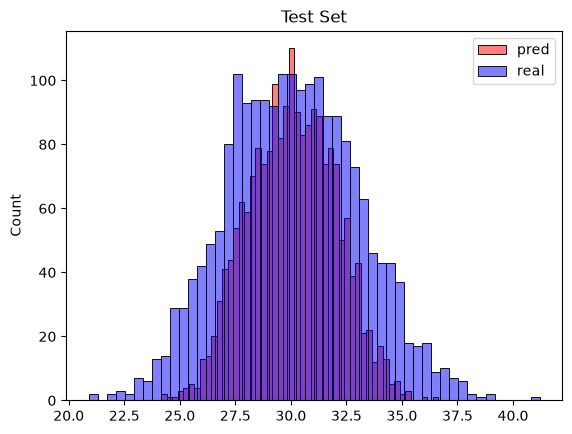

In [15]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val   = df.iloc[idx[n_train:n_train + n_val]]
df_test  = df.iloc[idx[n_train + n_val:]]

df_full_train = pd.concat([df_train, df_val])
df_full_train.horsepower = df_full_train.horsepower.fillna(0)
df_test.horsepower = df_test.horsepower.fillna(0)

feats = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

X_full_train = df_full_train[feats].values
X_test       = df_test[feats].values
y_full_train_real = df_full_train[target].values
y_test_real       = df_test[target].values

w0_full_train, w_full_train = linear_regression_reg(X=X_full_train, y=y_full_train_real, r=0.001)
y_test_pred = w0_full_train + X_test.dot(w_full_train)
rmse_test = rmse(y_real=y_test_real, y_pred=y_test_pred)

print(f"RMSE: {rmse_test.round(3)}")
sns.histplot(y_test_pred, label='pred', color='red',  alpha=0.5, bins=50)
sns.histplot(y_test_real, label='real', color='blue', alpha=0.5, bins=50)
plt.legend()
plt.title("Test Set")
plt.show()

Q6. What's the RMSE on the test dataset?

A6. 2.236